In [2]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
dataset_root = Path(
    "/Users/amirhossein/.cache/kagglehub/datasets/unclesamulus/blood-cells-image-dataset/versions/2"
)

print(os.listdir(dataset_root))

['bloodcells_dataset']


In [4]:
dataset_path = Path(
    "/Users/amirhossein/.cache/kagglehub/datasets/"
    "unclesamulus/blood-cells-image-dataset/"
    "versions/2/bloodcells_dataset"
)

print(dataset_path.exists())

True


In [5]:
class_counts = {}

for class_name in os.listdir(dataset_path):
    
    class_folder = dataset_path / class_name
    
    if class_folder.is_dir():
        class_counts[class_name] = len(
            list(class_folder.glob("*"))
        )

class_counts

{'basophil': 1218,
 'neutrophil': 3329,
 'ig': 2895,
 'monocyte': 1420,
 'eosinophil': 3117,
 'erythroblast': 1551,
 'lymphocyte': 1214,
 'platelet': 2348}

In [6]:
counts_df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Count"]
)

counts_df = counts_df.sort_values(
    "Count",
    ascending=False
)

counts_df

,Class,Count
1,neutrophil,3329
4,eosinophil,3117
2,ig,2895
7,platelet,2348
5,erythroblast,1551
3,monocyte,1420
0,basophil,1218
6,lymphocyte,1214


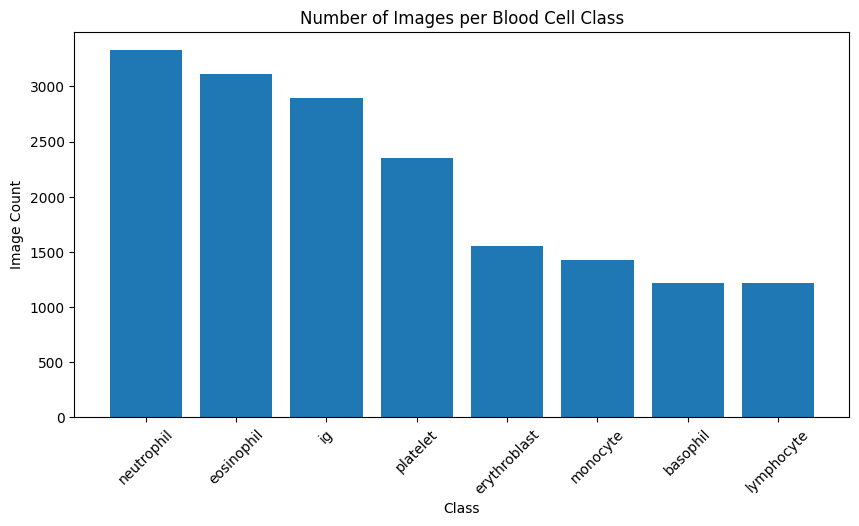

In [7]:
plt.figure(figsize=(10,5))

plt.bar(
    counts_df["Class"],
    counts_df["Count"]
)

plt.title("Number of Images per Blood Cell Class")
plt.xlabel("Class")
plt.ylabel("Image Count")

plt.xticks(rotation=45)

plt.show()

### Class Distribution

The dataset contains eight blood cell categories and exhibits moderate class imbalance.

Neutrophils and eosinophils contain the largest number of images, while basophils and lymphocytes contain the fewest.

The largest class contains approximately 2.7 times as many images as the smallest class, which may influence model training and evaluation.

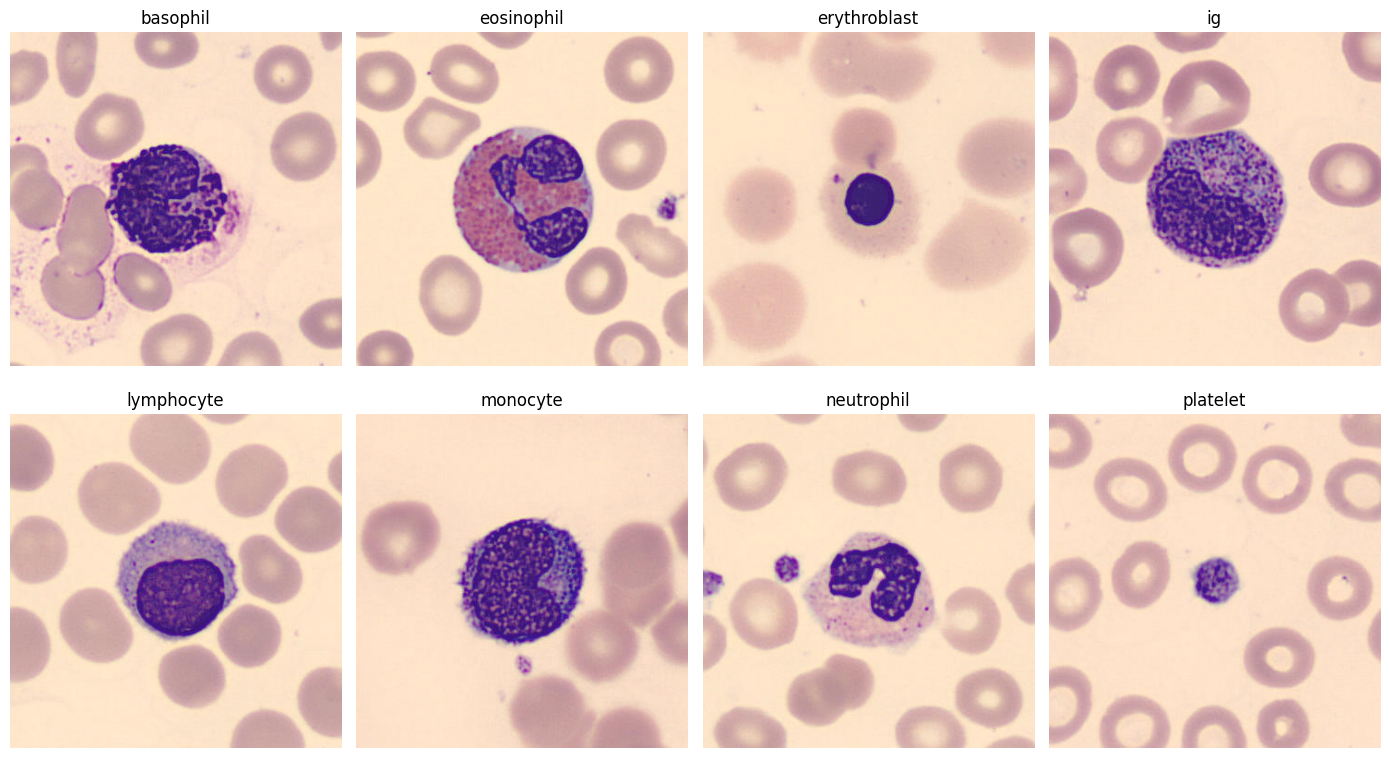

In [8]:
classes = sorted(class_counts.keys())

fig, axes = plt.subplots(
    2,
    4,
    figsize=(14,8)
)

axes = axes.flatten()

for ax, class_name in zip(axes, classes):

    image_path = next(
        (dataset_path / class_name).glob("*")
    )

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Sample Images

Visual inspection suggests that the blood cell classes have distinct morphological characteristics.

- Neutrophils and eosinophils exhibit segmented nuclei.
- Lymphocytes have a large, dense nucleus occupying most of the cell.
- Monocytes appear larger with more irregular internal structure.
- Platelets are significantly smaller than the other cell types.
- Basophils and immature granulocytes contain dense granulation patterns.

These visual differences suggest that deep learning models should be able to learn discriminative features for classification.

In [9]:
sizes = []

for class_name in class_counts.keys():

    class_folder = dataset_path / class_name

    for image_path in list(class_folder.glob("*"))[:100]:

        img = Image.open(image_path)

        sizes.append(img.size)

size_df = pd.DataFrame(
    sizes,
    columns=["Width", "Height"]
)

size_df.value_counts()

Width  Height
360    363       781
366    369        14
360    360         5
Name: count, dtype: int64

## Image Dimensions

Most images have dimensions of approximately 360 × 363 pixels, indicating a highly consistent image acquisition process.

A small number of images have slightly different dimensions, such as 366 × 369 or 360 × 360 pixels.

Because deep learning models such as ResNet50 require fixed-size inputs, all images will be resized during preprocessing.

In [10]:
size_df.describe()

,Width,Height
count,800.000000,800.000000
mean,360.105000,363.086250
std,0.787242,0.824415
min,360.000000,360.000000
25%,360.000000,363.000000
50%,360.000000,363.000000
75%,360.000000,363.000000
max,366.000000,369.000000
